In [ ]:
from pathlib import Path
from tempfile import TemporaryDirectory
from urllib.request import urlretrieve
from zipfile import ZipFile

from preflibtools.instances import OrdinalInstance

In [2]:

# PrefLib dataset zips matching your requested sources
PREFLIB_ZIPS = {
    "apa_election": "https://github.com/PrefLib/PrefLib-Data/releases/download/v1.0/00028_apa.zip",
    "sports_power_rankings": "https://github.com/PrefLib/PrefLib-Data/releases/download/v1.0/00056_seasonsport.zip",
    "eurovision": "https://github.com/PrefLib/PrefLib-Data/releases/download/v1.0/00064_eurovision.zip",
}

ORDINAL_EXTS = (".soc", ".soi", ".toc", ".toi")

def list_ordinal_files_in_zip(zip_url, limit=20):
    """Return ordinal-file members from a PrefLib zip (preview only)."""
    with TemporaryDirectory() as td:
        zip_path = Path(td) / "dataset.zip"
        urlretrieve(zip_url, zip_path)
        with ZipFile(zip_path, "r") as zf:
            members = [m for m in zf.namelist() if m.lower().endswith(ORDINAL_EXTS)]
    members.sort()
    return members[:limit], len(members)

def load_ordinal_instance_from_zip(zip_url, member_name=None):
    """Load one OrdinalInstance from a PrefLib dataset zip.

    If member_name is None, the first available ordinal file is used.
    """
    with TemporaryDirectory() as td:
        td_path = Path(td)
        zip_path = td_path / "dataset.zip"
        urlretrieve(zip_url, zip_path)

        with ZipFile(zip_path, "r") as zf:
            members = [m for m in zf.namelist() if m.lower().endswith(ORDINAL_EXTS)]
            members.sort()
            if not members:
                raise ValueError("No ordinal files found in zip archive.")
            target = member_name if member_name is not None else members[0]
            if target not in members:
                raise ValueError(f"Requested member not found: {target}")
            zf.extract(target, td_path)

        local_file = td_path / target
        instance = OrdinalInstance()
        instance.parse_file(str(local_file))
        return instance, target

# Preview what is inside each dataset zip
for name, url in PREFLIB_ZIPS.items():
    preview, total = list_ordinal_files_in_zip(url, limit=8)
    print(f"\n{name}: {total} ordinal files")
    for p in preview:
        print("  ", p)

# Example: load one APA election file (keeps downstream cells using `instance` working)
instance, loaded_member = load_ordinal_instance_from_zip(PREFLIB_ZIPS["apa_election"])
# Handle API differences across preflibtools versions
num_candidates = getattr(instance, "num_candidates", getattr(instance, "num_alternatives", None))
if num_candidates is None and hasattr(instance, "alternatives_name"):
    num_candidates = len(instance.alternatives_name)



URLError: <urlopen error [Errno 11001] getaddrinfo failed>

In [3]:
# Load one file from each dataset
instance_apa, _ = load_ordinal_instance_from_zip(PREFLIB_ZIPS["apa_election"])
instance_sports, _ = load_ordinal_instance_from_zip(PREFLIB_ZIPS["sports_power_rankings"])
instance_eurovision, _ = load_ordinal_instance_from_zip(PREFLIB_ZIPS["eurovision"])

for label, inst in [("apa_election", instance_apa), ("sports_power_rankings", instance_sports), ("eurovision", instance_eurovision)]:
    n_c = getattr(inst, "num_candidates", getattr(inst, "num_alternatives", None))
    if n_c is None and hasattr(inst, "alternatives_name"):
        n_c = len(inst.alternatives_name)
    print(f"{label}: {inst.num_voters} voters, {n_c} candidates")

apa_election: 18723 voters, 5 candidates
sports_power_rankings: 5 voters, 31 candidates
eurovision: 19 voters, 19 candidates


In [5]:
import numpy as np

def iter_pref_orders_with_counts(pref_orders):
    """Yield (count, order) pairs across common preflibtools order containers."""
    if hasattr(pref_orders, "items"):
        for order, count in pref_orders.items():
            yield count, order
        return
    for entry in pref_orders:
        if isinstance(entry, tuple) and len(entry) == 2 and isinstance(entry[0], int):
            count, order = entry
            yield count, order
        else:
            yield 1, entry

def orders_to_rank_matrix(instance):
    m = getattr(instance, "num_candidates", getattr(instance, "num_alternatives", None))
    if m is None and hasattr(instance, "alternatives_name"):
        m = len(instance.alternatives_name)
    if m is None:
        raise ValueError("Could not infer number of candidates from instance.")

    matrix = []
    for count, order in iter_pref_orders_with_counts(instance.orders):
        rank_vector = [0] * (m + 1)  # 1-indexed items
        for rank, item in enumerate(order, start=1):
            if isinstance(item, tuple):  # handle ties
                for i in item:
                    rank_vector[i] = rank
            else:
                rank_vector[item] = rank
        for _ in range(count):
            matrix.append(rank_vector[1:])  # drop the 0th index
    return np.array(matrix)

R_apa         = orders_to_rank_matrix(instance_apa)
R_sports      = orders_to_rank_matrix(instance_sports)
R_eurovision  = orders_to_rank_matrix(instance_eurovision)

print("R_apa shape:        ", R_apa.shape,        "  (assessors x candidates)")
print("R_sports shape:     ", R_sports.shape,     "  (assessors x candidates)")
print("R_eurovision shape: ", R_eurovision.shape, "  (assessors x candidates)")

R_apa shape:         (292, 5)   (assessors x candidates)
R_sports shape:      (5, 31)   (assessors x candidates)
R_eurovision shape:  (19, 19)   (assessors x candidates)


In [6]:
len(R_apa)

292

In [8]:
import time
from pathlib import Path

import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt

from model import *
import random
from sklearn.metrics import adjusted_rand_score
from scipy.optimize import linear_sum_assignment
from model.initialization import init_blocks_spectral, init_spectral_with_z
from helper_functions import *
from helper_functions.Estimate_p import estimate_p_multicluster, match_clusters

In [9]:
C = 20
gamma = 1.0
delta = 0.5

rankings_list = R_apa.tolist()
n_assessors_bb = len(rankings_list)
init_mu_bb = [n_assessors_bb / C for _ in range(C)]
p_hat_bb = 0.50

model_bb = MixtureRankingModel(
    rankings=rankings_list,
    #init_clusters=clusters_bb,
    n_clusters=C,
    init_mu=init_mu_bb,
    seed=42,
    verbose=True,
    init_theta=1.0,
)

final_state_bb, samples_bb = model_bb.run_mcmc(
    n_iter=15000,
    burn_in=10000,
    thin=1,
    save_samples=True,
    save_tau=True,
    save_theta=True,
    n_item_moves_per_cluster=1,
    gamma=gamma,
    delta=delta,
    a_theta=4,
    b_theta=1,
    theta_jump=10,
    use_annealing=True,
    temp_min=0.25,
    temp_max=1.0,
    tie_penalty=p_hat_bb,
)

if samples_bb is not None:
    summaries_bb = model_bb.estimate_map(samples_bb, ci=0.95)
    print("MAP-like summaries:", summaries_bb)

C:\Users\jonanord\AppData\Local\Temp\ipykernel_20312\4269778005.py:10: UserWarning: init_clusters not provided. For best results supply them via init_spectral_with_z(rankings, n_clusters=C, seed=...). Falling back to trivial initialization.
  model_bb = MixtureRankingModel(


[Model] Initialized: N=292 assessors, n=5 items, C=20 clusters, n_pairs=10
[Model] Compute:  CPU  (GPU unavailable — torch not installed)
[Model] U_all:    292×10  (0.0 MB float32, on CPU)
[Model] Parallel: N threshold = disabled
  Cluster 0: 3 blocks, theta=1.000, gamma=1.000, delta=0.500
  Cluster 1: 3 blocks, theta=1.000, gamma=1.000, delta=0.500
  Cluster 2: 3 blocks, theta=1.000, gamma=1.000, delta=0.500
  Cluster 3: 3 blocks, theta=1.000, gamma=1.000, delta=0.500
  Cluster 4: 3 blocks, theta=1.000, gamma=1.000, delta=0.500
  Cluster 5: 3 blocks, theta=1.000, gamma=1.000, delta=0.500
  Cluster 6: 3 blocks, theta=1.000, gamma=1.000, delta=0.500
  Cluster 7: 3 blocks, theta=1.000, gamma=1.000, delta=0.500
  Cluster 8: 3 blocks, theta=1.000, gamma=1.000, delta=0.500
  Cluster 9: 3 blocks, theta=1.000, gamma=1.000, delta=0.500
  Cluster 10: 3 blocks, theta=1.000, gamma=1.000, delta=0.500
  Cluster 11: 3 blocks, theta=1.000, gamma=1.000, delta=0.500
  Cluster 12: 3 blocks, theta=1.000,

In [10]:
model = model_bb 
model.print_acceptance_summary()


MCMC ACCEPTANCE SUMMARY

Log-posterior improvements: 2450/4999
Log-posterior improvement rate: 49.01%

Block moves acceptance (saved iterations = 5000):
  Cluster 0: 1650 accepts, acceptance_rate=33.00%
  Cluster 1: 2810 accepts, acceptance_rate=56.20%
  Cluster 2: 1739 accepts, acceptance_rate=34.78%
  Cluster 3: 1823 accepts, acceptance_rate=36.46%
  Cluster 4: 2043 accepts, acceptance_rate=40.86%
  Cluster 5: 1298 accepts, acceptance_rate=25.96%
  Cluster 6: 2363 accepts, acceptance_rate=47.26%
  Cluster 7: 2079 accepts, acceptance_rate=41.58%
  Cluster 8: 1906 accepts, acceptance_rate=38.12%
  Cluster 9: 1498 accepts, acceptance_rate=29.96%
  Cluster 10: 1319 accepts, acceptance_rate=26.38%
  Cluster 11: 1570 accepts, acceptance_rate=31.40%
  Cluster 12: 2485 accepts, acceptance_rate=49.70%
  Cluster 13: 1708 accepts, acceptance_rate=34.16%
  Cluster 14: 1601 accepts, acceptance_rate=32.02%
  Cluster 15: 1857 accepts, acceptance_rate=37.14%
  Cluster 16: 2164 accepts, acceptance_r

In [11]:
samples = samples_bb
map_result = model.find_map(samples, refine=True, verbose=True)

# Output:
# [MAP] Best sample at t=1234 with logp=-5432.10
#   Cluster 0: 12 moves in 3 sweeps, K=4 blocks
#   Cluster 1: 8 moves in 2 sweeps, K=3 blocks
# [MAP] logp: -5432.10 → -5428.55 (Δ=+3.55)

for c, cl in enumerate(map_result["clusters"]):
    print(f"Cluster {c}: {cl['blocks']}")

[MAP] Best sample at t=89 with logp=-2831.2530
  Cluster 0: 0 moves in 1 sweeps, K=4 blocks
  Cluster 1: 0 moves in 1 sweeps, K=3 blocks
  Cluster 2: 1 moves in 2 sweeps, K=5 blocks
  Cluster 3: 2 moves in 2 sweeps, K=3 blocks
  Cluster 4: 3 moves in 2 sweeps, K=5 blocks
  Cluster 5: 0 moves in 1 sweeps, K=3 blocks
  Cluster 6: 0 moves in 1 sweeps, K=2 blocks
  Cluster 7: 0 moves in 1 sweeps, K=2 blocks
  Cluster 8: 0 moves in 1 sweeps, K=2 blocks
  Cluster 9: 0 moves in 1 sweeps, K=3 blocks
  Cluster 10: 2 moves in 2 sweeps, K=3 blocks
  Cluster 11: 0 moves in 1 sweeps, K=1 blocks
  Cluster 12: 0 moves in 1 sweeps, K=2 blocks
  Cluster 13: 1 moves in 2 sweeps, K=3 blocks
  Cluster 14: 0 moves in 1 sweeps, K=2 blocks
  Cluster 15: 0 moves in 1 sweeps, K=2 blocks
  Cluster 16: 0 moves in 1 sweeps, K=2 blocks
  Cluster 17: 0 moves in 1 sweeps, K=3 blocks
  Cluster 18: 0 moves in 1 sweeps, K=3 blocks
  Cluster 19: 0 moves in 1 sweeps, K=2 blocks
[MAP] logp: -2831.2530 → -2819.1775 (Δ=+12.

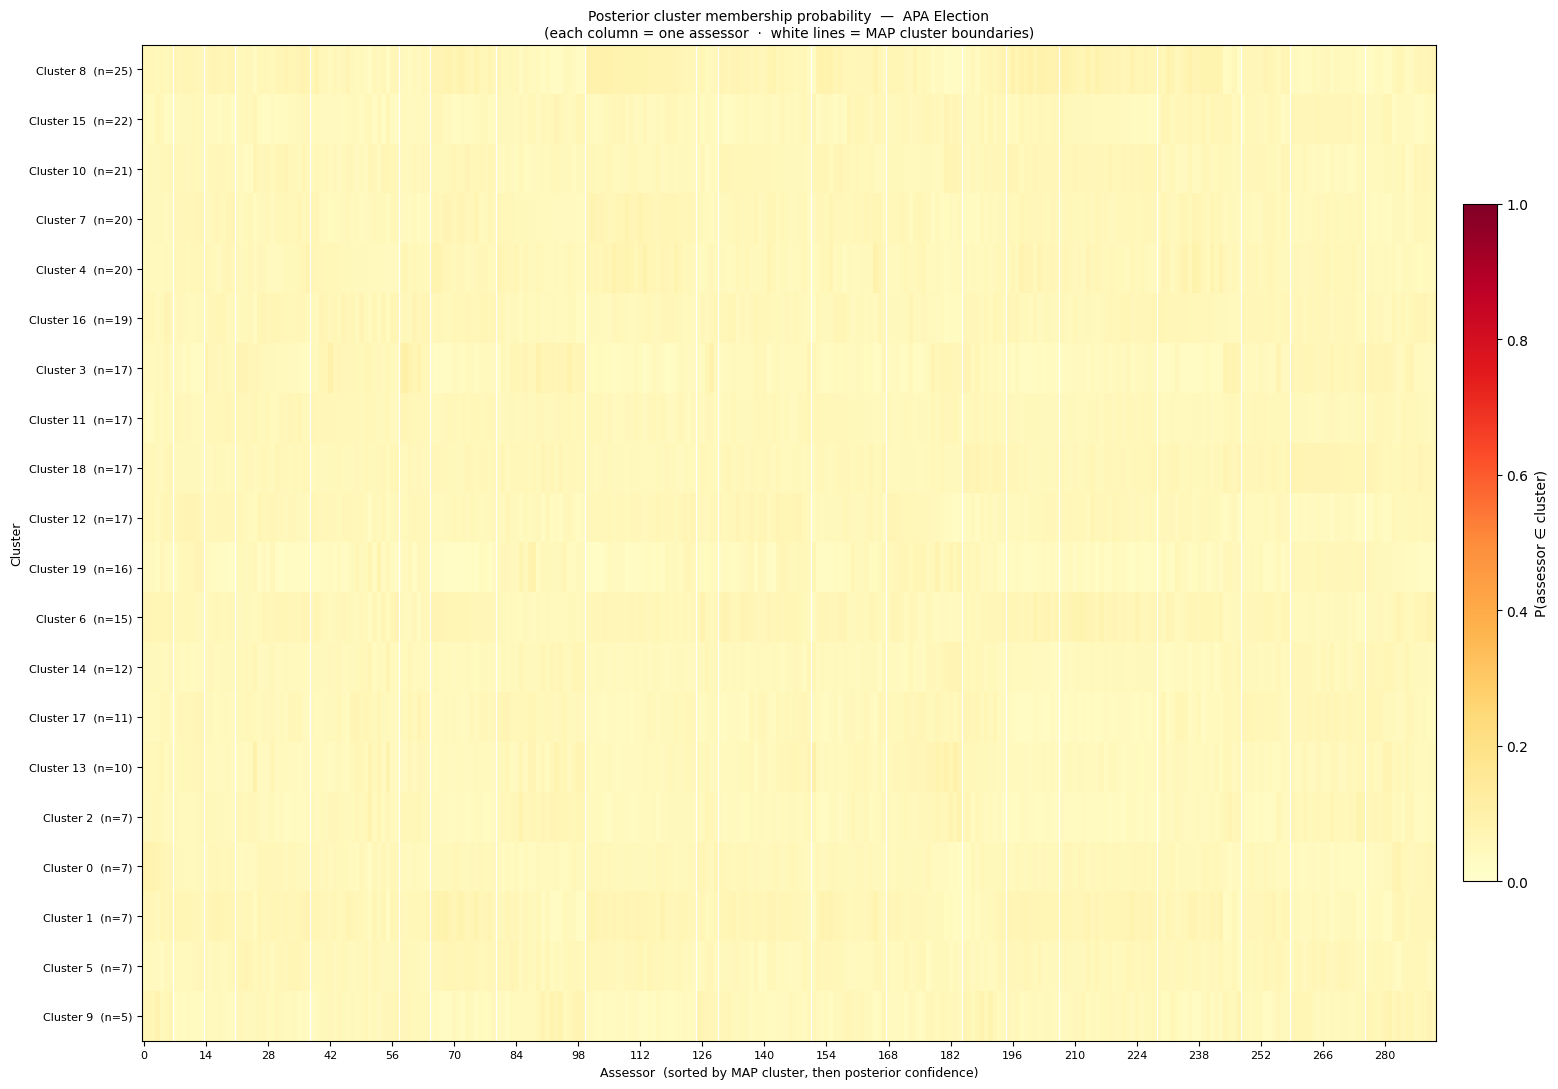

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# ── Posterior membership matrix ───────────────────────────────────────────────
# membership[i, c] = fraction of post-burn-in samples where assessor i was in cluster c
z_arr   = np.array(samples.z_samples, dtype=np.intp)   # (T, N)
T_samp  = z_arr.shape[0]
N_assessors = len(rankings_list)

membership = np.zeros((N_assessors, C), dtype=np.float32)
for t in range(T_samp):
    membership[np.arange(N_assessors), z_arr[t]] += 1
membership /= T_samp

# ── Sort assessors by MAP cluster, then by posterior confidence desc ──────────
z_map_arr  = np.array(map_result["z"], dtype=int)
confidence = membership[np.arange(N_assessors), z_map_arr]

sort_ord   = np.lexsort((-confidence, z_map_arr))   # primary: cluster, secondary: -confidence
boundaries = np.where(np.diff(z_map_arr[sort_ord]))[0]

# ── Sort clusters rows: by cluster size (most assessors first) ───────────────
cluster_sizes = np.array([(z_map_arr == c).sum() for c in range(C)])
active_clusters = [c for c in np.argsort(-cluster_sizes) if cluster_sizes[c] > 0]
inactive        = [c for c in range(C) if cluster_sizes[c] == 0]
row_order       = active_clusters + inactive   # inactive clusters at the bottom

mem_display = membership[sort_ord][:, row_order]   # (N, C_displayed)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(max(12, N_assessors * 0.04 + 4), max(5, len(active_clusters) * 0.45 + 2)))

im = ax.imshow(
    mem_display.T, vmin=0, vmax=1, cmap="YlOrRd",
    aspect="auto", interpolation="nearest",
)

# MAP cluster boundary lines (vertical)
for b in boundaries:
    ax.axvline(b + 0.5, color="white", lw=0.9, alpha=0.9)

# Separator between active and inactive clusters (horizontal)
if inactive:
    ax.axhline(len(active_clusters) - 0.5, color="white", lw=1.5, linestyle="--", alpha=0.7)

# Cluster labels on y-axis
ax.set_yticks(range(len(row_order)))
ax.set_yticklabels(
    [f"Cluster {c}  (n={cluster_sizes[c]})" for c in row_order],
    fontsize=8,
)

# Assessor index ticks on x-axis (sparse for readability)
tick_step = max(1, N_assessors // 20)
ax.set_xticks(range(0, N_assessors, tick_step))
ax.set_xticklabels(range(0, N_assessors, tick_step), fontsize=8)

ax.set_xlabel("Assessor  (sorted by MAP cluster, then posterior confidence)", fontsize=9)
ax.set_ylabel("Cluster", fontsize=9)
ax.set_title(
    "Posterior cluster membership probability  —  APA Election\n"
    "(each column = one assessor  ·  white lines = MAP cluster boundaries)",
    fontsize=10,
)
plt.colorbar(im, ax=ax, label="P(assessor ∈ cluster)", fraction=0.025, pad=0.02)
plt.tight_layout()
plt.show()

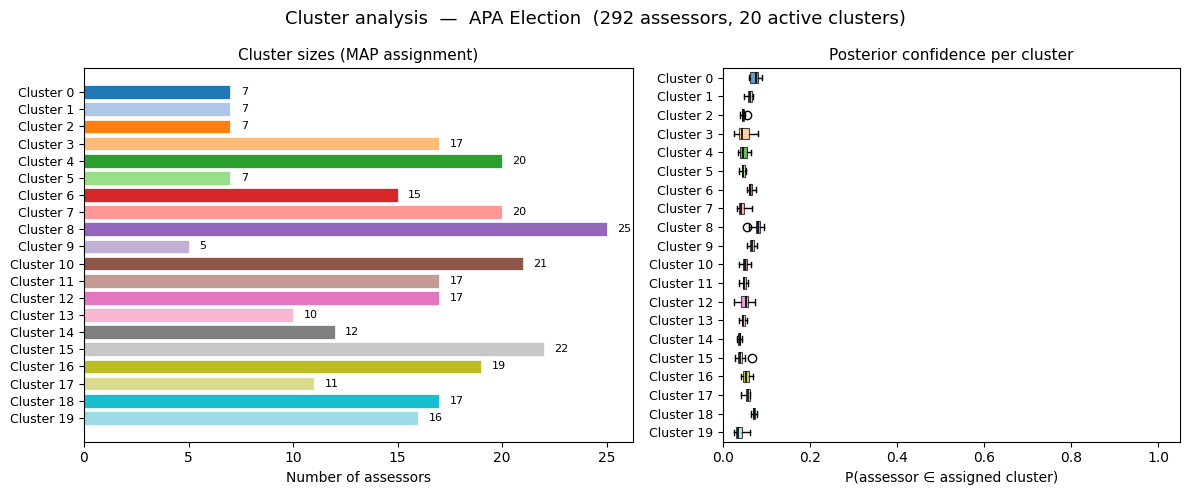

In [14]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ── MAP cluster assignments ───────────────────────────────────────────────────
z_map = np.array(map_result["z"], dtype=int)

# Only show active clusters (non-empty)
active = sorted([c for c in range(C) if (z_map == c).sum() > 0])
n_active = len(active)
sizes = [(z_map == c).sum() for c in active]

# ── Color map ────────────────────────────────────────────────────────────────
cmap_cl = plt.get_cmap("tab20" if n_active > 10 else "tab10", max(n_active, 1))
cl_color = {c: cmap_cl(i / max(n_active - 1, 1)) for i, c in enumerate(active)}

# ── Figure: 2 panels ─────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), width_ratios=[1.2, 1])

# --- Panel 1: Cluster sizes bar chart ---
bars = ax1.barh(range(n_active), sizes, color=[cl_color[c] for c in active],
                edgecolor="white", linewidth=0.5)
ax1.set_yticks(range(n_active))
ax1.set_yticklabels([f"Cluster {c}" for c in active], fontsize=9)
ax1.set_xlabel("Number of assessors", fontsize=10)
ax1.set_title("Cluster sizes (MAP assignment)", fontsize=11)
ax1.invert_yaxis()

for i, (bar, sz) in enumerate(zip(bars, sizes)):
    ax1.text(bar.get_width() + 0.5, i, str(sz), va="center", fontsize=8)

# --- Panel 2: Posterior confidence distribution per cluster ---
confidence_per_cluster = {}
for c in active:
    mask = z_map == c
    conf = membership[mask, c]
    confidence_per_cluster[c] = conf

positions = list(range(n_active))
bp = ax2.boxplot(
    [confidence_per_cluster[c] for c in active],
    positions=positions, vert=False, widths=0.6,
    patch_artist=True,
    boxprops=dict(linewidth=0.8),
    medianprops=dict(color="black", linewidth=1.2),
)
for patch, c in zip(bp["boxes"], active):
    patch.set_facecolor(cl_color[c])
    patch.set_alpha(0.7)

ax2.set_yticks(positions)
ax2.set_yticklabels([f"Cluster {c}" for c in active], fontsize=9)
ax2.set_xlabel("P(assessor ∈ assigned cluster)", fontsize=10)
ax2.set_title("Posterior confidence per cluster", fontsize=11)
ax2.set_xlim(0, 1.05)
ax2.invert_yaxis()

fig.suptitle(f"Cluster analysis  —  APA Election  ({N_assessors} assessors, {n_active} active clusters)", fontsize=13)
fig.tight_layout()
plt.show()

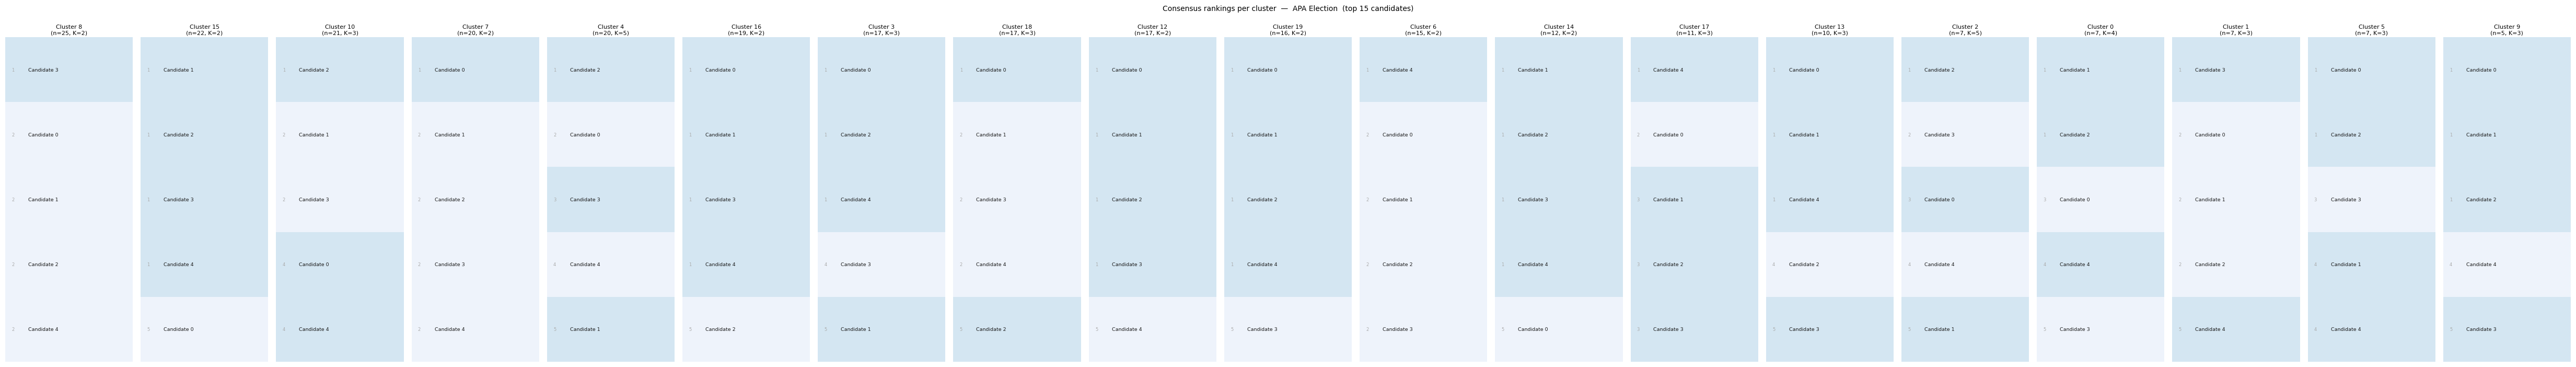

Showing 19 of 20 clusters  (filter: ≥5 voters, ≥2 blocks)
Excluded: [11]


In [15]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

TOP_K         = 15   # top rank positions shown per cluster
MIN_VOTERS    = 5    # exclude clusters with fewer voters than this
MIN_BLOCKS    = 2    # exclude clusters whose consensus has fewer blocks than this

# ── Candidate names from instance ─────────────────────────────────────────────
candidate_names = {}
if hasattr(instance_apa, "alternatives_name"):
    candidate_names = dict(instance_apa.alternatives_name)
elif hasattr(instance_apa, "alternatives_names"):
    candidate_names = dict(instance_apa.alternatives_names)

# ── MAP cluster assignments ───────────────────────────────────────────────────
z_map = np.array(map_result["z"], dtype=int)

# ── Filter clusters ───────────────────────────────────────────────────────────
def _n_blocks(c):
    return len(map_result["clusters"][c]["blocks"])

cluster_sizes_arr = np.array([(z_map == c).sum() for c in range(C)])

cluster_order = [
    c for c in np.argsort(-cluster_sizes_arr)
    if cluster_sizes_arr[c] >= MIN_VOTERS
    and _n_blocks(c) >= MIN_BLOCKS
]

if not cluster_order:
    print("No clusters passed the filters — lower MIN_VOTERS or MIN_BLOCKS.")
else:
    # ── Extract top-K candidates from block structure ─────────────────────────
    def top_k_from_blocks(blocks, k):
        rows, pos = [], 1
        for b_idx, block in enumerate(blocks):
            for item_idx in block:
                name = candidate_names.get(item_idx, f"Candidate {item_idx}")
                rows.append((pos, b_idx, name))
            pos += len(block)
            if pos > k:
                break
        return [r for r in rows if r[0] <= k]

    # ── Figure ────────────────────────────────────────────────────────────────
    ncols    = len(cluster_order)
    block_bg = ["#eef3fb", "#d4e6f2"]
    cmap_cl  = plt.get_cmap("tab20" if ncols > 10 else "tab10", max(ncols, 1))

    fig, axes = plt.subplots(
        1, ncols,
        figsize=(ncols * 2.6, TOP_K * 0.37 + 1.5),
        squeeze=False,
    )

    for col, c in enumerate(cluster_order):
        blocks   = map_result["clusters"][c]["blocks"]
        top_rows = top_k_from_blocks(blocks, TOP_K)
        total    = int(cluster_sizes_arr[c])
        n_blk    = len(blocks)

        ax_r = axes[0, col]
        ax_r.set_xlim(0, 1)
        ax_r.set_ylim(0, max(len(top_rows), 1))
        ax_r.invert_yaxis()
        ax_r.axis("off")
        ax_r.set_title(
            f"Cluster {c}\n(n={total}, K={n_blk})",
            fontsize=8, pad=4,
        )

        prev_block, toggle = -1, 0
        for row_i, (rank_pos, b_idx, name) in enumerate(top_rows):
            if b_idx != prev_block:
                toggle, prev_block = 1 - toggle, b_idx
            ax_r.add_patch(plt.Rectangle(
                (0, row_i), 1, 1, facecolor=block_bg[toggle], edgecolor="none", zorder=1,
            ))
            ax_r.text(0.05, row_i + 0.5, str(rank_pos),
                      fontsize=6, va="center", ha="left", color="#aaaaaa", zorder=2)
            short = name if len(name) <= 22 else name[:21] + "…"
            ax_r.text(0.18, row_i + 0.5, short,
                      fontsize=6.8, va="center", ha="left", color="#1a1a1a", zorder=2)

    fig.suptitle(
        f"Consensus rankings per cluster  —  APA Election  (top {TOP_K} candidates)",
        fontsize=10, y=0.99,
    )
    fig.tight_layout()
    plt.show()

    print(
        f"Showing {ncols} of {C} clusters  "
        f"(filter: ≥{MIN_VOTERS} voters, ≥{MIN_BLOCKS} blocks)\n"
        f"Excluded: {[c for c in range(C) if c not in cluster_order]}"
    )